# SaoCheck AI — MVP Model Training

## Classification de la véracité des contenus

Projet : SaoCheck AI  
Organisation : WenakLabs / SaoCheck  
Programme : AI for Good Fellowship — Code for Africa

### Objectif

Développer un premier prototype NLP capable de classer une affirmation
dans l'une des quatre catégories :

- TRUE
- FALSE
- MISLEADING
- UNVERIFIED

⚠️ Le dataset actuellement utilisé contient des données de démonstration
synthétiques. Les performances obtenues ne représentent donc pas encore
la performance réelle du système SaoCheck AI.

In [ ]:
import torch

print("PyTorch version :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("⚠️ Aucun GPU détecté.")
    print("Dans Colab : Runtime > Change runtime type > GPU")

PyTorch version : 2.11.0+cu128
CUDA disponible : True
GPU : Tesla T4


In [ ]:
!pip -q install -U transformers datasets evaluate accelerate openpyxl scikit-learn
!pip -q install pandas==2.2.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 36.1 MB/s eta 0:00:00


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from datasets import Dataset, DatasetDict

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed
)

In [ ]:
SEED = 42
set_seed(SEED)

PROJECT_NAME = "SaoCheck_AI_MVP"

MODEL_NAME = "camembert-base"

OUTPUT_DIR = "./saocheck_misinformation_model"

print("Projet :", PROJECT_NAME)
print("Modèle :", MODEL_NAME)
print("Seed :", SEED)


Projet : SaoCheck_AI_MVP
Modèle : camembert-base
Seed : 42


In [ ]:
from google.colab import files
import pandas as pd

# Sélectionner à nouveau le fichier Excel
uploaded = files.upload()

# Récupérer le nom du fichier
filename = list(uploaded.keys())[0]

print("Fichier chargé :", filename)

Saving SaoCheck_AI_MVP_Dataset.xlsx to SaoCheck_AI_MVP_Dataset (1).xlsx
Fichier chargé : SaoCheck_AI_MVP_Dataset (1).xlsx


In [ ]:
excel_file = pd.ExcelFile(filename)

print("Feuilles disponibles :")

for i, sheet in enumerate(excel_file.sheet_names, start=1):
    print(f"{i}. {sheet}")

Feuilles disponibles :
1. README
2. MVP Dataset
3. Data Dictionary
4. Label Statistics


In [ ]:
# Charger la feuille contenant les données du MVP

df = pd.read_excel(
    filename,
    sheet_name="MVP Dataset"
)

print("Dataset chargé avec succès.")
print("Nombre de lignes :", len(df))
print("Nombre de colonnes :", len(df.columns))

df.head()

Dataset chargé avec succès.
Nombre de lignes : 50
Nombre de colonnes : 21


,content_id,source,platform,published_at,collected_at,language,title,text,claim,topic,...,sentiment,claim_veracity,misinformation_risk,hate_speech,risk_level,evidence_url,evidence_note,annotator_id,review_status,is_demo_data
0,SC-0001,SaoCheck Demo,Facebook,2026-07-01,2026-07-02,fr,Exemple de contenu 1 — Politique,Une publication affirme qu'une nouvelle mesure...,qu'une nouvelle mesure publique entre en vigue...,Politique,...,Positive,True,Potential,Uncertain,Low,NaN,Démonstration — référence à confirmer par SaoC...,DEMO_ANNOTATOR_01,Demo - Not Reviewed,YES
1,SC-0002,Source publique – démonstration,X,2026-07-02,2026-07-04,fr,Exemple de contenu 2 — Élections,Un message partagé en ligne annonce une fermet...,annonce une fermeture de services publics sans...,Élections,...,Neutral,Unverified,Low,No,High,NaN,NaN,DEMO_ANNOTATOR_01,Demo - Not Reviewed,YES
2,SC-0003,Media Demo,Website,2026-07-03,2026-07-06,fr,Exemple de contenu 3 — Santé,Une vidéo présente une information sanitaire e...,une information sanitaire et recommande de vér...,Santé,...,Negative,Misleading,Medium,No,Medium,NaN,Démonstration — référence à confirmer par SaoC...,DEMO_ANNOTATOR_01,Demo - Not Reviewed,YES
3,SC-0004,Social Media Demo,TikTok,2026-07-04,2026-07-08,fr,Exemple de contenu 4 — Sécurité,Un compte affirme qu'un chiffre économique réc...,qu'un chiffre économique récent prouve une amé...,Sécurité,...,Positive,False,High,No,Low,NaN,Démonstration — référence à confirmer par SaoC...,DEMO_ANNOTATOR_01,Demo - Not Reviewed,YES
4,SC-0005,SaoCheck Demo,YouTube,2026-07-05,2026-07-10,fr,Exemple de contenu 5 — Conflit,Une publication attribue à une institution une...,à une institution une déclaration qui doit êtr...,Conflit,...,Neutral,True,Potential,No,High,NaN,Démonstration — référence à confirmer par SaoC...,DEMO_ANNOTATOR_01,Demo - Not Reviewed,YES


In [ ]:
# Préparation des données pour l'entraînement

df_model = df.copy()

# Nettoyer le texte
df_model["text"] = df_model["text"].fillna("").astype(str)

# Nettoyer les labels
df_model["claim_veracity"] = (
    df_model["claim_veracity"]
    .fillna("")
    .astype(str)
    .str.upper()
    .str.strip()
)

# Garder uniquement les textes exploitables
df_model = df_model[
    df_model["text"].str.len() > 10
].copy()

print("Nombre de lignes :", len(df_model))

print("\nRépartition des classes :")
print(df_model["claim_veracity"].value_counts())

Nombre de lignes : 50

Répartition des classes :
claim_veracity
TRUE          13
UNVERIFIED    13
MISLEADING    12
FALSE         12
Name: count, dtype: int64


In [ ]:
# Correspondance entre les classes et les nombres

label2id = {
    "TRUE": 0,
    "FALSE": 1,
    "MISLEADING": 2,
    "UNVERIFIED": 3
}

id2label = {
    0: "TRUE",
    1: "FALSE",
    2: "MISLEADING",
    3: "UNVERIFIED"
}

df_model["label"] = df_model["claim_veracity"].map(label2id)

print("Labels :")
print(label2id)

print("\nVérification :")
print(df_model[["text", "claim_veracity", "label"]].head())

Labels :
{'TRUE': 0, 'FALSE': 1, 'MISLEADING': 2, 'UNVERIFIED': 3}

Vérification :
                                                text claim_veracity  label
0  Une publication affirme qu'une nouvelle mesure...           TRUE      0
1  Un message partagé en ligne annonce une fermet...     UNVERIFIED      3
2  Une vidéo présente une information sanitaire e...     MISLEADING      2
3  Un compte affirme qu'un chiffre économique réc...          FALSE      1
4  Une publication attribue à une institution une...           TRUE      0


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_model,
    test_size=0.30,
    random_state=42,
    stratify=df_model["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train       :", len(train_df))
print("Validation  :", len(val_df))
print("Test        :", len(test_df))
print("Total       :", len(train_df) + len(val_df) + len(test_df))

Train       : 35
Validation  : 7
Test        : 8
Total       : 50


In [ ]:
# Vérification des valeurs manquantes

missing = df.isnull().sum()

print("Valeurs manquantes par colonne :")
print(missing[missing > 0])

Valeurs manquantes par colonne :
evidence_url     50
evidence_note    13
dtype: int64


In [ ]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[["text", "label"]],
        preserve_index=False
    ),
    "validation": Dataset.from_pandas(
        val_df[["text", "label"]],
        preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df[["text", "label"]],
        preserve_index=False
    )
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 35
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 7
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 8
    })
})


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "camembert-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer chargé avec succès.")
print("Modèle :", MODEL_NAME)

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

Tokenizer chargé avec succès.
Modèle : camembert-base


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=256
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

print(tokenized_dataset)

Map:   0%|          | 0/35 [00:00<?, ? examples/s]

Map:   0%|          | 0/7 [00:00<?, ? examples/s]

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 35
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 7
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 8
    })
})


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

print("Modèle CamemBERT chargé avec succès.")
print("Nombre de classes :", model.config.num_labels)
print("Classes :", model.config.id2label)

model.safetensors: reconstructing file:   0%|          |  0.00B /  445MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modèle CamemBERT chargé avec succès.
Nombre de classes : 4
Classes : {0: 'TRUE', 1: 'FALSE', 2: 'MISLEADING', 3: 'UNVERIFIED'}


In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

print("Device utilisé :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU non disponible")

Device utilisé : cuda
GPU : Tesla T4


In [ ]:
# Colonnes nécessaires à l'entraînement

columns_to_keep = [
    "input_ids",
    "attention_mask",
    "label"
]

tokenized_dataset = tokenized_dataset.remove_columns(
    [
        column
        for column in tokenized_dataset["train"].column_names
        if column not in columns_to_keep
    ]
)

# Format PyTorch
tokenized_dataset.set_format(
    "torch",
    columns=columns_to_keep
)

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 35
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 7
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 8
    })
})


In [ ]:
# Vérification avant entraînement

print("Train :", len(tokenized_dataset["train"]))
print("Validation :", len(tokenized_dataset["validation"]))
print("Test :", len(tokenized_dataset["test"]))

print("\nColonnes :", tokenized_dataset["train"].column_names)

print("\nPremier exemple :")
print(tokenized_dataset["train"][0])

Train : 35
Validation : 7
Test : 8

Colonnes : ['label', 'input_ids', 'attention_mask']

Premier exemple :
{'label': tensor(0), 'input_ids': tensor([    5,   180,  2254,  5104,    46,    11,    70, 11773,    33,   101,
        23866,    29,   247, 12681,    10,   112,  2146,     8,  1878,  2711,
            9,     6]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./saocheck_camembert",

    # Évaluation et sauvegarde
    eval_strategy="epoch",
    save_strategy="epoch",

    # Paramètres d'entraînement
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=5,

    # Régularisation
    weight_decay=0.01,

    # Meilleur modèle
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Rapports
    report_to="none",

    # GPU
    fp16=torch.cuda.is_available()
)

print("Configuration d'entraînement créée.")

Configuration d'entraînement créée.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Fonction de calcul des métriques prête.")

Fonction de calcul des métriques prête.


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

print("Trainer SaoCheck créé avec succès.")

Trainer SaoCheck créé avec succès.


In [ ]:
train_result = trainer.train()

print("\nEntraînement terminé.")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,1.384487,0.285714,0.171429,0.285714,0.190476
2,No log,1.377232,0.285714,0.171429,0.285714,0.190476
3,No log,1.365932,0.428571,0.190476,0.428571,0.261905
4,No log,1.355469,0.428571,0.190476,0.428571,0.261905
5,No log,1.351283,0.428571,0.190476,0.428571,0.261905


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Entraînement terminé.
TrainOutput(global_step=45, training_loss=1.3584003024631077, metrics={'train_runtime': 229.0175, 'train_samples_per_second': 0.764, 'train_steps_per_second': 0.196, 'total_flos': 1813546070232.0, 'train_loss': 1.3584003024631077, 'epoch': 5.0})


In [ ]:
# Évaluation finale sur le jeu de test

test_results = trainer.evaluate(
    tokenized_dataset["test"]
)

print("Résultats sur le TEST :")

for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
No log,1.374756,5,0.500000,0.375000,0.500000,0.416667


Résultats sur le TEST :
eval_loss: 1.3748
eval_accuracy: 0.5000
eval_precision: 0.3750
eval_recall: 0.5000
eval_f1: 0.4167


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Prédictions sur le jeu de test
predictions = trainer.predict(
    tokenized_dataset["test"]
)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=-1
)

true_labels = predictions.label_ids

# Rapport détaillé
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=[
        id2label[0],
        id2label[1],
        id2label[2],
        id2label[3]
    ],
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

        TRUE       0.50      0.50      0.50         2
       FALSE       0.00      0.00      0.00         2
  MISLEADING       0.50      0.50      0.50         2
  UNVERIFIED       0.50      1.00      0.67         2

    accuracy                           0.50         8
   macro avg       0.38      0.50      0.42         8
weighted avg       0.38      0.50      0.42         8



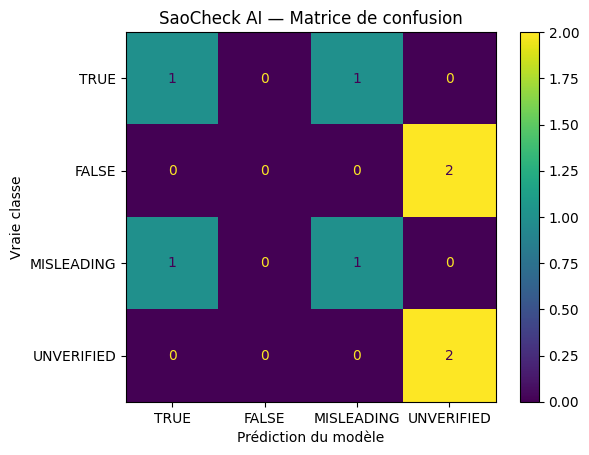

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=[0, 1, 2, 3]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "TRUE",
        "FALSE",
        "MISLEADING",
        "UNVERIFIED"
    ]
)

disp.plot()

plt.title("SaoCheck AI — Matrice de confusion")
plt.xlabel("Prédiction du modèle")
plt.ylabel("Vraie classe")
plt.show()